In [1]:
# Load required libraries
library(data.table)
library(dplyr)
library(ggplot2)
library(ggpubr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Visit order
bmmc_tx_tp <- c(
    'PreTx',
    'EI',
    'ASCT90d',
    'ASCT1y',
    'ASCT2y',
    'Healthy'
)


tp_color_map <- c(
    'PreTx' = '#8B0000',
    'PI2C' = '#C20272',
    'EI' = '#7502C2',
    'ASCT60d' = '#0021B0',
    'ASCT90d' = '#2346DE',
    'ASCT1y' = '#038AFF',
    'ASCT2y' = '#008080',
    'Healthy' = '#00470D'
)

color_map <- c(
  "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
  "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
  "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
  "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
  "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

In [3]:
# Load data
df <- fread('../../../data/rna/pseudobulk/outputs/bmmc_l3_frequency.csv')
df <- df[df$label.visitDetails != '',]
df <- df[!is.na(label.visitDetails), ]

# create visit order
df[, label.visitDetails := factor(label.visitDetails, levels = bmmc_tx_tp)]
df <- df %>%
  mutate(
    label.visitDetails = factor(label.visitDetails),
    celltype_label = factor(aifi_plot_l3, levels = levels(factor(aifi_plot_l3)))
  )


In [4]:
# Load manual p-values
manual_pvals <- fread("../../../data/rna/pseudobulk/results/freq_results/bmmc_all_timepoint_frequency_results.csv")
manual_pvals <- manual_pvals %>%
  mutate(
    group1 = factor(group1, levels = bmmc_tx_tp),
    group2 = factor(group2, levels = bmmc_tx_tp),
    celltype_label = factor(aifi_plot_l3, levels = levels(df$celltype_label)),
    p.adj.signif = case_when(
      p.adj < 0.001 ~ "***",
      p.adj < 0.01 ~ "**",
      p.adj < 0.05 ~ "*",
      TRUE ~ "ns"
    )
  ) %>%
  filter(p.adj.signif != "ns")

In [5]:
# Define your exact comparison order
comparison_order <- c(
  "PreTx-PI2C", "PreTx-EI", "PI2C-EI", "EI-ASCT60d", "EI-ASCT1y", "EI-ASCT2y",
  "ASCT60d-ASCT1y", "ASCT1y-ASCT2y", 
  "PreTx-Healthy", "PI2C-Healthy", "EI-Healthy", "ASCT60d-Healthy", "ASCT1y-Healthy", "ASCT2y-Healthy"
)

In [6]:
# Calculate y-positions for each cell type separately
manual_pvals_positioned <- manual_pvals %>%
  mutate(
    comparison_id = paste(group1, group2, sep = "-")
  ) %>%
  group_by(celltype_label) %>%
  mutate(
    max_y = max(df$cell_type_clr[df$celltype_label == first(celltype_label)], na.rm = TRUE),
    comparison_rank = match(comparison_id, comparison_order)
  ) %>%
  arrange(celltype_label, comparison_rank) %>%
  group_by(celltype_label) %>%
  mutate(
    y.position = max_y + 0.1 + (row_number() - 1) * 0.3
  ) %>%
  ungroup()

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `max_y = max(...)`.
ℹ In group 41: `celltype_label = NA`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf”


In [7]:
# Split data by comparison type
healthy_comparisons <- manual_pvals_positioned %>% filter(group2 == "Healthy")
other_comparisons <- manual_pvals_positioned %>% filter(group2 != "Healthy")

In [8]:
# Create the plot with new aesthetics
p <- ggplot(df, aes(x = label.visitDetails, y = cell_type_clr)) +
  geom_boxplot(
    aes(fill = label.visitDetails),
    alpha = 0.85,
    outlier.shape = NA,
    color = "black"
  ) +
  # Add subject lines if you have subject ID column
  {if("subject.subjectGuid" %in% colnames(df)) {
    geom_line(
      aes(group = subject.subjectGuid, color = subject.subjectGuid),
      alpha = 0.5, 
      linewidth = 0.5
    )
  }} +
  # Add jittered points
  geom_jitter(
    aes(color = if("subject.subjectGuid" %in% colnames(df)) subject.subjectGuid else label.visitDetails,
        shape = manual.flu_response),
    width = 0.2,
    size = 1.5,
    stroke = 0.4,
    alpha = 0.9
  ) +
  facet_wrap(~ celltype_label, scales = "free_y", ncol = 6) +
  labs(
    title = "BMMC - Frequency analysis over treatment time points",
    subtitle = "BMMC excludes plasma cells.\nPaired Wilcoxon signed-rank test for longitudinal comparisons; Unpaired Wilcoxon rank-sum test (Mann-Whitney U) for healthy comparisons.\nFDR correction applied within each comparison. Significance: * p < 0.05  |  ** p < 0.01  |  *** p < 0.001",
    x = "Visit Timepoints",
    y = "Centered Log Ratio"
  ) +
  theme_linedraw(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18, margin = margin(b = 10)),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "right",
    legend.title = element_blank(),
    strip.text = element_text(size = 14, face = "bold", colour = "black"),
    strip.background = element_rect(fill = "white", color = "black")
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  scale_fill_manual(values = tp_color_map) +
  scale_color_manual(values = if("subject.subjectGuid" %in% colnames(df)) color_map else tp_color_map)

# Add black brackets for non-healthy comparisons
if(nrow(other_comparisons) > 0) {
  p <- p + stat_pvalue_manual(
    other_comparisons,
    label = "p.adj.signif",
    tip.length = 0.01,
    size = 4,
    step.increase = 0,
    inherit.aes = FALSE
  )
}

# Add pink brackets for healthy comparisons using a custom approach
if(nrow(healthy_comparisons) > 0) {
  # Create a custom layer for green brackets
  healthy_brackets <- healthy_comparisons %>%
    rowwise() %>%
    mutate(
      x1 = as.numeric(group1),
      x2 = as.numeric(group2),
      xmid = (x1 + x2) / 2
    ) %>%
    ungroup()
  
  p <- p + 
    # Add horizontal line
    geom_segment(data = healthy_brackets,
                 aes(x = x1, xend = x2, y = y.position, yend = y.position),
                 color = "#b52267", inherit.aes = FALSE, linewidth = 0.5, alpha=0.8) +
    # Add left vertical line  
    geom_segment(data = healthy_brackets,
                 aes(x = x1, xend = x1, y = y.position - 0.08, yend = y.position),
                 color = "#b52267", inherit.aes = FALSE, linewidth = 0.5, alpha=0.8) +
    # Add right vertical line
    geom_segment(data = healthy_brackets,
                 aes(x = x2, xend = x2, y = y.position - 0.08, yend = y.position),
                 color = "#b52267", inherit.aes = FALSE, linewidth = 0.5, alpha=0.8) +
    # Add significance text
    geom_text(data = healthy_brackets,
              aes(x = xmid, y = y.position + 0.03, label = p.adj.signif),
              color = "#b52267", inherit.aes = FALSE, size = 4, alpha=0.8)
}

ggsave("../../../data/rna/pseudobulk/results/freq_plots/bmmc_boxplot_all.png", p, width = 30, height = 35, dpi = 300)

Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_text()`).”


In [9]:
options(repr.plot.width = 30, repr.plot.height = 35)

Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_text()`).”


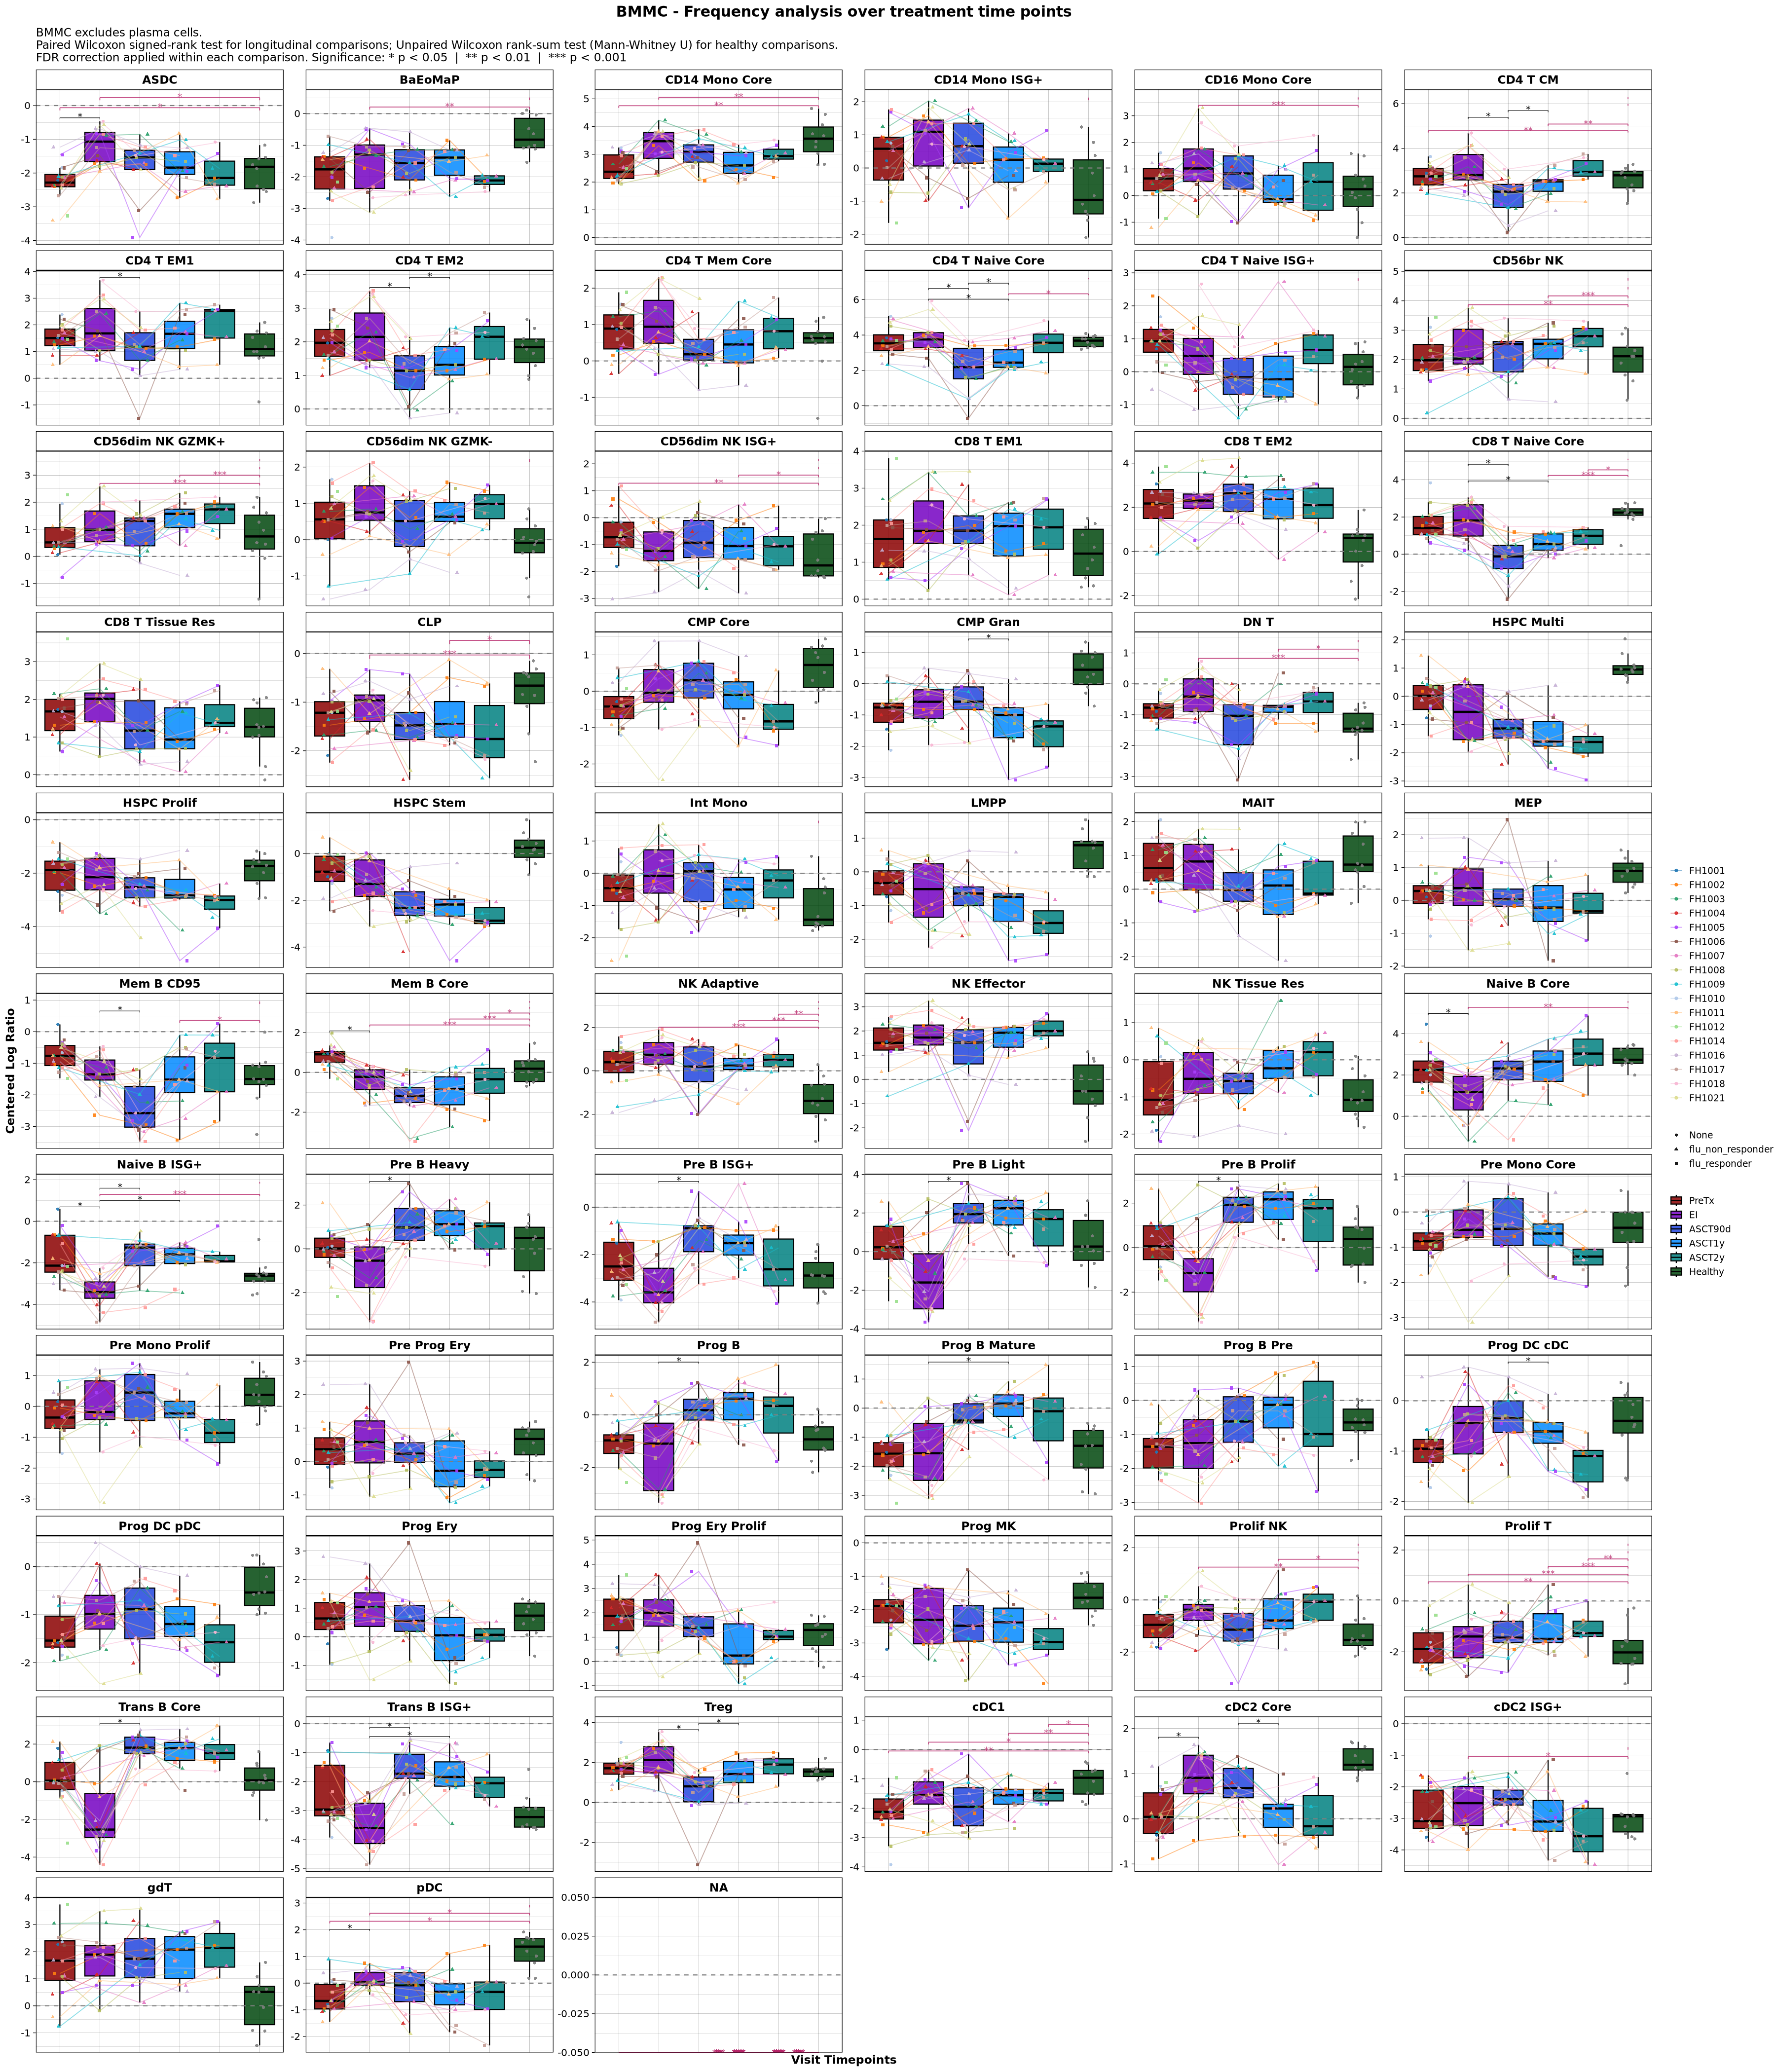

In [10]:
p